In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sahilislam007/college-student-placement-factors-dataset")

print("Path to dataset files:", path)

c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Kimo Store\.cache\kagglehub\datasets\sahilislam007\college-student-placement-factors-dataset\versions\1


In [2]:
import pandas as pd
import os

print(os.listdir(path))

['college_student_placement_dataset.csv']


In [3]:
csv_path = os.path.join(path, "college_student_placement_dataset.csv")
df = pd.read_csv(csv_path)

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
#Check info
print("\nDataset info:")
print(df.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
None


In [5]:
# Drop
df = df.drop(columns=['College_ID'])

In [6]:
# Encode categorical columns
encoder = LabelEncoder()
df['Internship_Experience'] = encoder.fit_transform(df['Internship_Experience'])
df['Placement'] = encoder.fit_transform(df['Placement'])

In [7]:
# Define X and y
X = df.drop(columns=['Placement'])
y = df['Placement']

In [8]:
print("\nFeatures (X):")
print(X.head())


Features (X):
    IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0  107             6.61  6.28                     8                      0   
1   97             5.52  5.37                     8                      0   
2  109             5.36  5.83                     9                      0   
3  122             5.47  5.75                     6                      1   
4   96             7.91  7.69                     7                      0   

   Extra_Curricular_Score  Communication_Skills  Projects_Completed  
0                       8                     8                   4  
1                       7                     8                   0  
2                       3                     1                   1  
3                       1                     6                   1  
4                       8                    10                   2  


In [9]:
print("\nTarget (y):")
print(y.head())


Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Placement, dtype: int64


In [10]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Decision Tree Model
dt = DecisionTreeClassifier(random_state=42, max_depth=3, criterion='gini')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [12]:
print("\nDecision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 0.963
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1674
           1       0.85      0.94      0.89       326

    accuracy                           0.96      2000
   macro avg       0.92      0.95      0.94      2000
weighted avg       0.97      0.96      0.96      2000



In [13]:
# Random Forest Model
rf = RandomForestClassifier(random_state=42, n_estimators=100, criterion='gini')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [14]:
print("\nRandom Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [15]:
#Plot Desicion Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

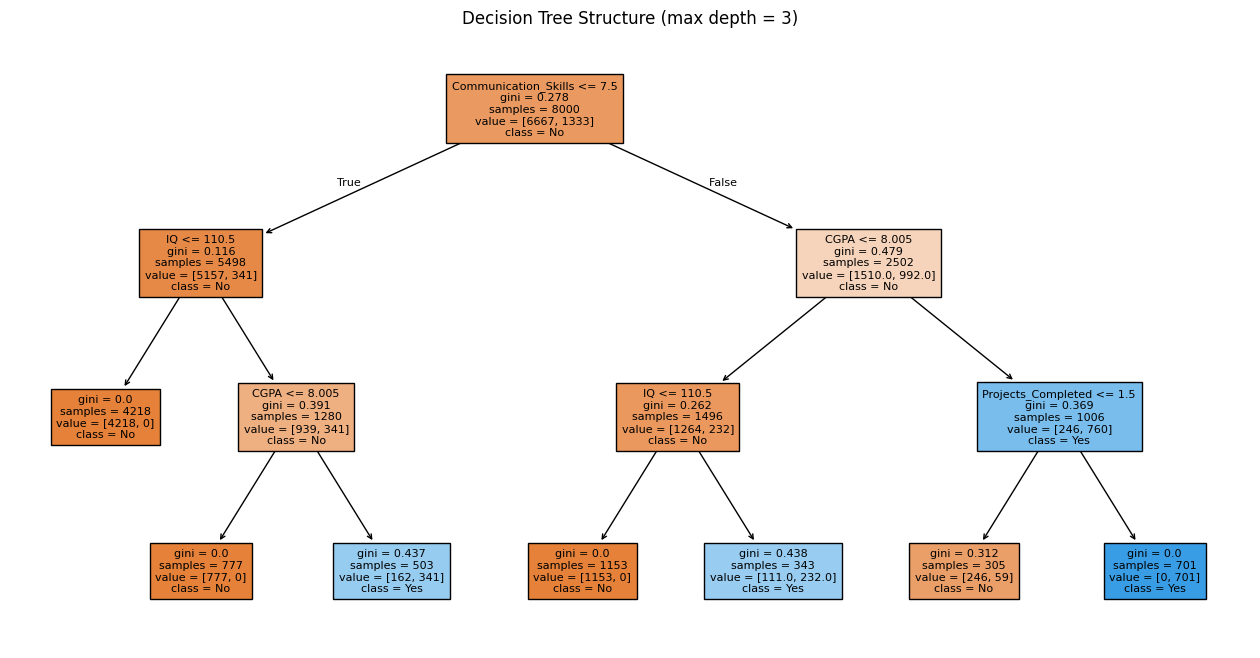

In [16]:
#Plot DT
plt.figure(figsize=(16,8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          fontsize=8)
plt.title("Decision Tree Structure (max depth = 3)")
plt.show()

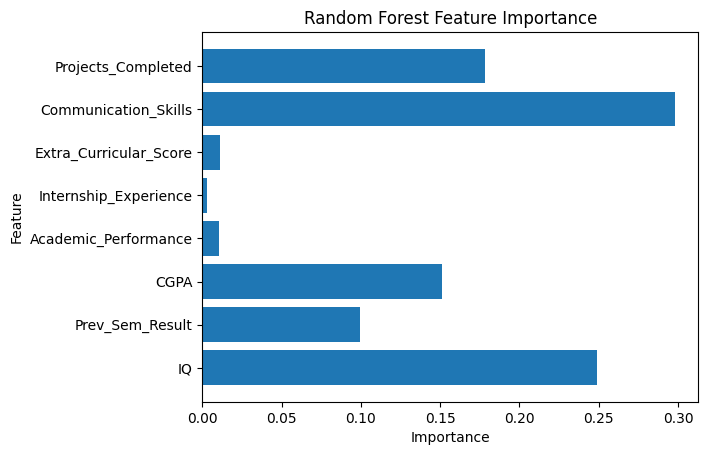

In [17]:
#Plot Random Forest
plt.barh(X.columns, rf.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()